COSC502 FINAL PROJECT AARON JOHNSON

In [1]:
# ============================================================
# SETUP AND IMPORTS
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import re
from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.tokenize import word_tokenize

from wordcloud import WordCloud

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    silhouette_score
)

from sklearn.metrics.pairwise import cosine_similarity

# Download NLTK resources
for resource in ["punkt", "stopwords", "wordnet", "averaged_perceptron_tagger"]:
    nltk.download(resource, quiet=True)

print("Setup complete.")

Setup complete.


In [2]:
# ----------------------------------------------------------------
# Read the CSV into a pandas DataFrame.
# ----------------------------------------------------------------

df_imdb = pd.read_csv("movie_data.csv")

print("Shape:", df_imdb.shape)

print("\nSentiment Counts:")
print(df_imdb["sentiment"].value_counts())

df_imdb.head(3)

Shape: (50000, 2)

Sentiment Counts:
sentiment
1    25000
0    25000
Name: count, dtype: int64


,review,sentiment
0,I went and saw this movie last night after bei...,1
1,Actor turned director Bill Paxton follows up h...,1
2,As a recreational golfer with some knowledge o...,1


In [3]:
# ----------------------------------------------------------------
# Split the dataset into training and testing sets.
# ----------------------------------------------------------------

X = df_imdb["review"]
y = df_imdb["sentiment"]

test_size = 0.30
random_seed = 42

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=test_size,
    random_state=random_seed,
    stratify=y
)

print(f"Training samples : {len(X_train_raw):,}")
print(f"Test samples     : {len(X_test_raw):,}")

Training samples : 35,000
Test samples     : 15,000


In [4]:
# ----------------------------------------------------------------
# Text preprocessing
# Steps:
#   1. Lowercase text
#   2. Remove HTML tags
#   3. Remove numbers and punctuation
#   4. Tokenize words
#   5. Remove stop words, but keep negation words
#   6. Lemmatize words
# ----------------------------------------------------------------

import string

lemmatizer = WordNetLemmatizer()

# Keep important negation words for sentiment analysis
negation_words = {"not", "no", "nor", "never"}
stop_words = set(stopwords.words("english")) - negation_words

punctuation_table = str.maketrans("", "", string.punctuation)

def preprocess(text: str) -> str:
    """Clean and normalize movie review text."""
    
    if pd.isna(text):
        return ""
    
    text = text.lower()
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"\d+", " ", text)
    text = text.translate(punctuation_table)
    
    tokens = word_tokenize(text)
    
    tokens = [
        lemmatizer.lemmatize(token)
        for token in tokens
        if token not in stop_words
    ]
    
    return " ".join(tokens)

print("Pre-processing training set...")
X_train_clean = X_train_raw.apply(preprocess)

print("Pre-processing test set...")
X_test_clean = X_test_raw.apply(preprocess)

print("\nOriginal:")
print(X_train_raw.iloc[0][:120])

print("\nCleaned:")
print(X_train_clean.iloc[0][:120])

Pre-processing training set...
Pre-processing test set...

Original:
At the time I recall being quite startled and amused by this movie. I referred to it as the most important movie I'd see

Cleaned:
time recall quite startled amused movie referred important movie id seen ten year found bumping people said similar thin


In [5]:
# ----------------------------------------------------------------
# Convert cleaned text into TF-IDF feature matrices.
# ----------------------------------------------------------------

def build_tfidf_features(X_train, X_test, ngram_range=(1, 1), max_features=10_000):
    vectorizer = TfidfVectorizer(
        ngram_range=ngram_range,
        max_features=max_features,
        min_df=2,
        max_df=0.90,
        sublinear_tf=True
    )

    X_train_tfidf = vectorizer.fit_transform(X_train)
    X_test_tfidf = vectorizer.transform(X_test)

    return vectorizer, X_train_tfidf, X_test_tfidf


tfidf_uni, X_train_uni, X_test_uni = build_tfidf_features(
    X_train_clean,
    X_test_clean,
    ngram_range=(1, 1)
)

tfidf_bi, X_train_bi, X_test_bi = build_tfidf_features(
    X_train_clean,
    X_test_clean,
    ngram_range=(1, 2)
)

print("Unigram feature matrix:", X_train_uni.shape)
print("Bigram  feature matrix:", X_train_bi.shape)

Unigram feature matrix: (35000, 10000)
Bigram  feature matrix: (35000, 10000)


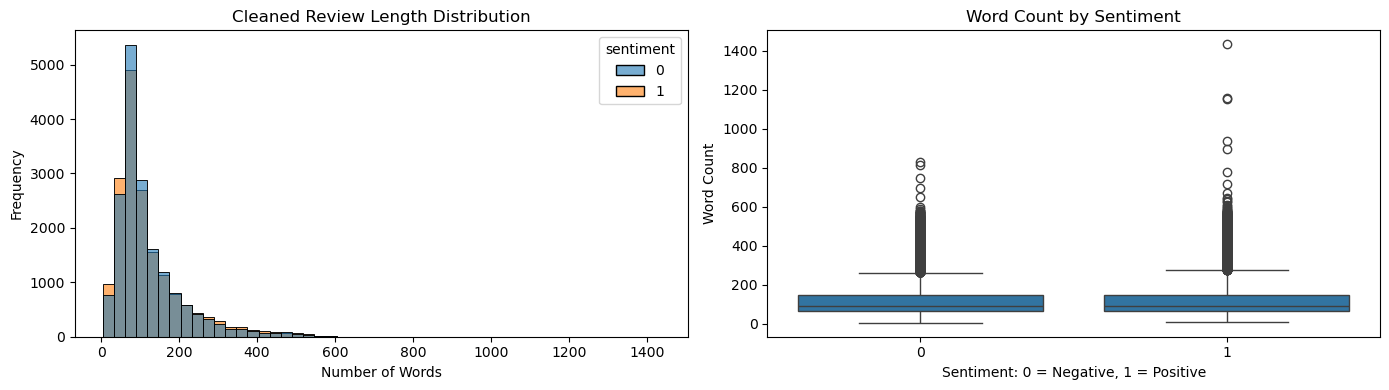

In [6]:
# ----------------------------------------------------------------
# Review Length Distribution
# Count the number of words in each cleaned review and compare
# the distribution for positive vs. negative reviews.
# ----------------------------------------------------------------

df_train = pd.DataFrame({
    "text": X_train_clean.values,
    "sentiment": y_train.values
})

df_train["word_count"] = df_train["text"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram of cleaned review lengths
sns.histplot(
    data=df_train,
    x="word_count",
    hue="sentiment",
    bins=50,
    alpha=0.6,
    ax=axes[0]
)

axes[0].set_title("Cleaned Review Length Distribution")
axes[0].set_xlabel("Number of Words")
axes[0].set_ylabel("Frequency")

# Boxplot comparison by sentiment
sns.boxplot(
    data=df_train,
    x="sentiment",
    y="word_count",
    ax=axes[1]
)

axes[1].set_title("Word Count by Sentiment")
axes[1].set_xlabel("Sentiment: 0 = Negative, 1 = Positive")
axes[1].set_ylabel("Word Count")

plt.tight_layout()
plt.show()

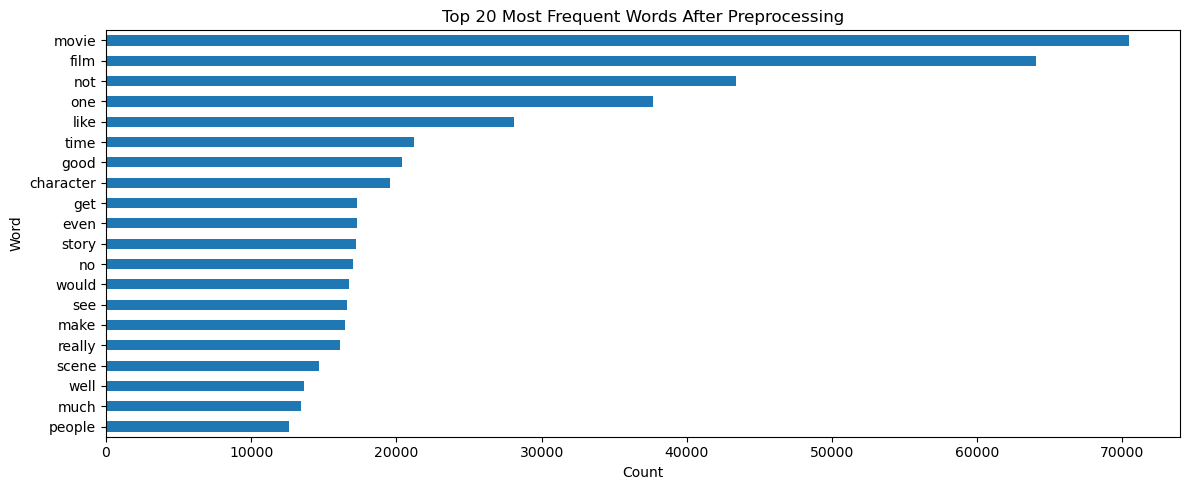

In [7]:
# ----------------------------------------------------------------
# Word Frequency Analysis
# Count the most common words across all cleaned training reviews.
# ----------------------------------------------------------------

top_words = (
    df_train["text"]
    .str.split()
    .explode()
    .value_counts()
    .head(20)
)

plt.figure(figsize=(12, 5))
top_words.sort_values().plot(kind="barh")

plt.title("Top 20 Most Frequent Words After Preprocessing")
plt.xlabel("Count")
plt.ylabel("Word")
plt.tight_layout()
plt.show()

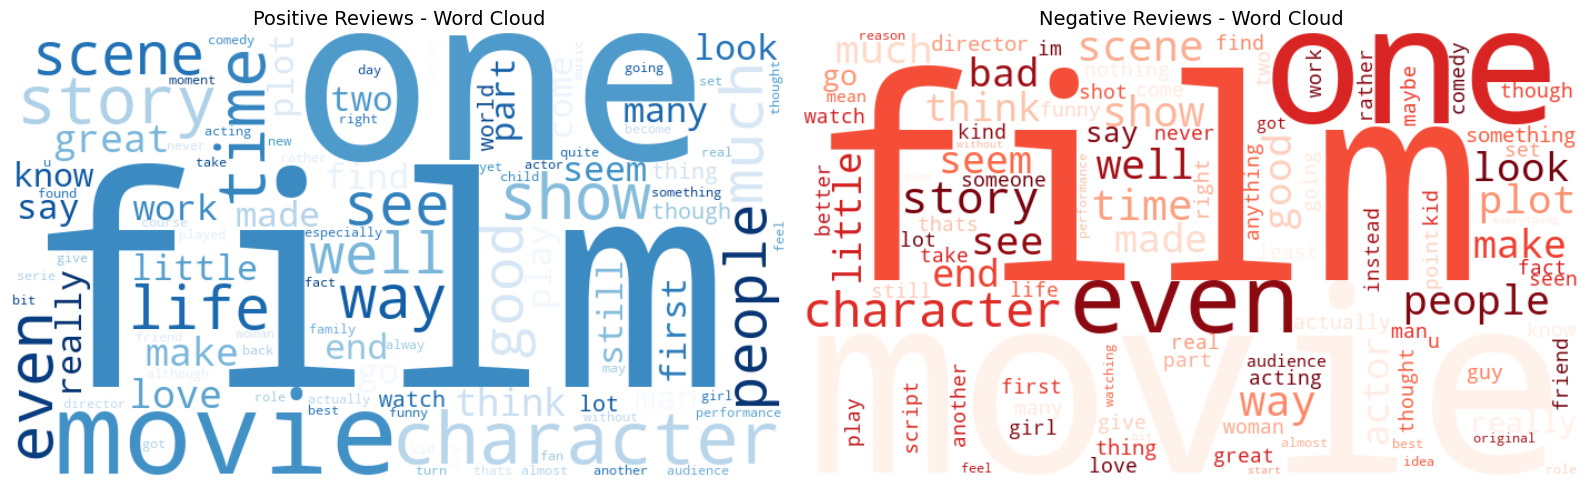

In [8]:
# ----------------------------------------------------------------
# Positive vs Negative Word Clouds
# These word clouds show the most frequent words in each sentiment class.
# ----------------------------------------------------------------

pos_text = " ".join(df_train.loc[df_train["sentiment"] == 1, "text"])
neg_text = " ".join(df_train.loc[df_train["sentiment"] == 0, "text"])

def create_wordcloud(text, colormap):
    if not text.strip():
        return None
    return WordCloud(
        width=700,
        height=400,
        background_color="white",
        colormap=colormap,
        max_words=100
    ).generate(text)

wc_pos = create_wordcloud(pos_text, "Blues")
wc_neg = create_wordcloud(neg_text, "Reds")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

if wc_pos:
    axes[0].imshow(wc_pos, interpolation="bilinear")
axes[0].axis("off")
axes[0].set_title("Positive Reviews - Word Cloud", fontsize=14)

if wc_neg:
    axes[1].imshow(wc_neg, interpolation="bilinear")
axes[1].axis("off")
axes[1].set_title("Negative Reviews - Word Cloud", fontsize=14)

plt.tight_layout()
plt.show()

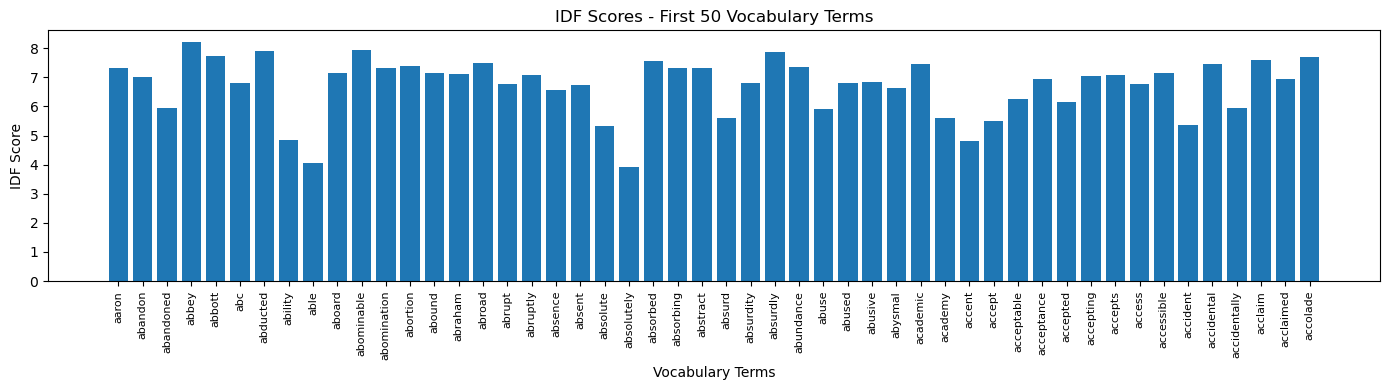

In [9]:
# ----------------------------------------------------------------
# IDF Scores for the First 50 Vocabulary Terms
# IDF measures how rare a term is across the training corpus.
# Higher IDF = rarer term.
# ----------------------------------------------------------------

vocab = tfidf_uni.get_feature_names_out()
idf_scores = tfidf_uni.idf_

first_50_terms = vocab[:50]
first_50_idfs = idf_scores[:50]

plt.figure(figsize=(14, 4))
plt.bar(range(len(first_50_terms)), first_50_idfs)

plt.xticks(
    range(len(first_50_terms)),
    first_50_terms,
    rotation=90,
    fontsize=8
)

plt.title("IDF Scores - First 50 Vocabulary Terms")
plt.xlabel("Vocabulary Terms")
plt.ylabel("IDF Score")
plt.tight_layout()
plt.show()

In [10]:
# ----------------------------------------------------------------
# Train and evaluate multiple classifiers on unigram and bigram TF-IDF.
# ----------------------------------------------------------------

from sklearn.neural_network import MLPClassifier

def evaluate_clf(model, X_train, X_test, y_train, y_test):
    """
    Train a classifier and return predictions, probabilities, and metrics.
    """

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    metrics = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

    return metrics, y_pred, y_prob


feature_sets = {
    "Unigram": (X_train_uni, X_test_uni),
    "Bigram": (X_train_bi, X_test_bi)
}

models = {
    "LogReg": LogisticRegression(max_iter=1000, random_state=42),
    "RandomForest": RandomForestClassifier(
        n_estimators=100,
        n_jobs=-1,
        random_state=42
    ),
    "ANN": MLPClassifier(
        hidden_layer_sizes=(256, 128),
        activation="relu",
        max_iter=30,
        random_state=42
    )
}

results_q1 = []
trained_models = {}

for feature_name, (X_train_features, X_test_features) in feature_sets.items():
    for model_name, model in models.items():

        full_model_name = f"{model_name}-{feature_name}"

        metrics, y_pred, y_prob = evaluate_clf(
            model,
            X_train_features,
            X_test_features,
            y_train,
            y_test
        )

        results_q1.append({
            "Model": full_model_name,
            **metrics
        })

        trained_models[full_model_name] = {
            "model": model,
            "y_pred": y_pred,
            "y_prob": y_prob
        }

        print(f"{full_model_name} Accuracy: {metrics['Accuracy']:.4f}")


results_df = pd.DataFrame(results_q1).sort_values(
    by="F1",
    ascending=False
)

results_df

LogReg-Unigram Accuracy: 0.8957
RandomForest-Unigram Accuracy: 0.8521
ANN-Unigram Accuracy: 0.8738
LogReg-Bigram Accuracy: 0.9017
RandomForest-Bigram Accuracy: 0.8573
ANN-Bigram Accuracy: 0.8771


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
3,LogReg-Bigram,0.901733,0.895199,0.910000,0.902539,0.963436
0,LogReg-Unigram,0.895733,0.887569,0.906267,0.896820,0.960185
5,ANN-Bigram,0.877067,0.874669,0.880267,0.877459,0.947880
2,ANN-Unigram,0.873800,0.870392,0.878400,0.874378,0.944535
4,RandomForest-Bigram,0.857267,0.858366,0.855733,0.857047,0.933572
1,RandomForest-Unigram,0.852133,0.857085,0.845200,0.851101,0.929289


K= 1  Euclidean: 0.7703  Cosine: 0.7703  
K= 2  Euclidean: 0.7726  Cosine: 0.7726  
K= 3  Euclidean: 0.7924  Cosine: 0.7924  
K= 4  Euclidean: 0.7980  Cosine: 0.7980  
K= 5  Euclidean: 0.7991  Cosine: 0.7991  
K= 6  Euclidean: 0.8070  Cosine: 0.8070  
K= 7  Euclidean: 0.8101  Cosine: 0.8101  
K= 8  Euclidean: 0.8143  Cosine: 0.8143  
K= 9  Euclidean: 0.8140  Cosine: 0.8140  
K=10  Euclidean: 0.8160  Cosine: 0.8160  
K=11  Euclidean: 0.8203  Cosine: 0.8203  
K=12  Euclidean: 0.8234  Cosine: 0.8234  
K=13  Euclidean: 0.8226  Cosine: 0.8226  
K=14  Euclidean: 0.8221  Cosine: 0.8221  
K=15  Euclidean: 0.8220  Cosine: 0.8220  
K=16  Euclidean: 0.8279  Cosine: 0.8279  
K=17  Euclidean: 0.8259  Cosine: 0.8259  
K=18  Euclidean: 0.8283  Cosine: 0.8283  
K=19  Euclidean: 0.8249  Cosine: 0.8249  
K=20  Euclidean: 0.8274  Cosine: 0.8274  
K=21  Euclidean: 0.8271  Cosine: 0.8271  
K=22  Euclidean: 0.8287  Cosine: 0.8287  
K=23  Euclidean: 0.8264  Cosine: 0.8264  
K=24  Euclidean: 0.8280  Cosine: 0

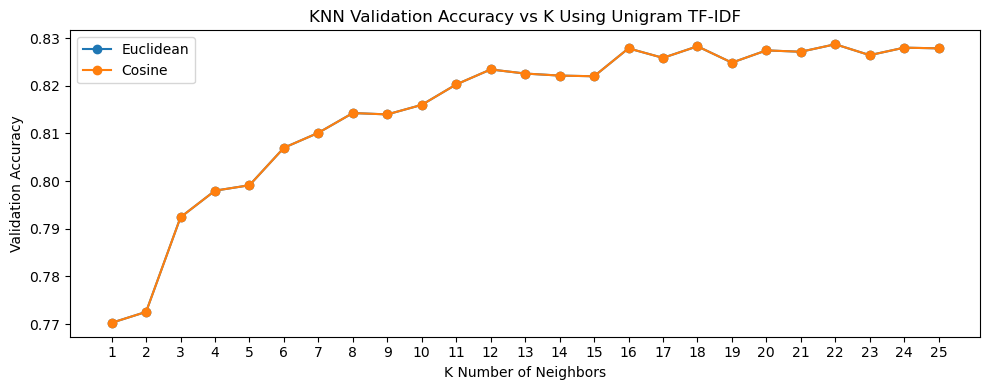

Best KNN Configuration:
{'metric_name': 'Euclidean', 'metric': 'euclidean', 'best_k': 22, 'validation_accuracy': 0.8287142857142857}


In [11]:
# ----------------------------------------------------------------
# KNN Model Selection Using a Validation Set
# ----------------------------------------------------------------

X_train_knn, X_val_knn, y_train_knn, y_val_knn = train_test_split(
    X_train_uni,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

k_values = range(1, 26)

metrics = {
    "Euclidean": {
        "metric": "euclidean",
        "val_scores": []
    },
    "Cosine": {
        "metric": "cosine",
        "val_scores": []
    }
}

for k in k_values:
    print(f"K={k:2d}", end="  ")

    for name, config in metrics.items():
        knn = KNeighborsClassifier(
            n_neighbors=k,
            metric=config["metric"],
            n_jobs=-1
        )

        knn.fit(X_train_knn, y_train_knn)
        y_val_pred = knn.predict(X_val_knn)

        val_accuracy = accuracy_score(y_val_knn, y_val_pred)
        config["val_scores"].append(val_accuracy)

        print(f"{name}: {val_accuracy:.4f}", end="  ")

    print()

plt.figure(figsize=(10, 4))

for name, config in metrics.items():
    plt.plot(k_values, config["val_scores"], marker="o", label=name)

plt.xlabel("K Number of Neighbors")
plt.ylabel("Validation Accuracy")
plt.title("KNN Validation Accuracy vs K Using Unigram TF-IDF")
plt.xticks(list(k_values))
plt.legend()
plt.tight_layout()
plt.show()

# Find the best metric and K from validation results
best_results = []

for name, config in metrics.items():
    best_index = np.argmax(config["val_scores"])
    best_k = list(k_values)[best_index]
    best_val_score = config["val_scores"][best_index]

    best_results.append({
        "metric_name": name,
        "metric": config["metric"],
        "best_k": best_k,
        "validation_accuracy": best_val_score
    })

best_knn_result = max(best_results, key=lambda x: x["validation_accuracy"])

print("Best KNN Configuration:")
print(best_knn_result)

In [12]:
best_knn = KNeighborsClassifier(
    n_neighbors=best_knn_result["best_k"],
    metric=best_knn_result["metric"],
    n_jobs=-1
)

best_knn.fit(X_train_uni, y_train)

y_pred_knn = best_knn.predict(X_test_uni)

print("Final KNN Test Performance")
print("Accuracy :", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred_knn, zero_division=0))
print("F1 Score :", f1_score(y_test, y_pred_knn, zero_division=0))

Final KNN Test Performance
Accuracy : 0.8256
Precision: 0.8152594887683966
Recall   : 0.842
F1 Score : 0.8284140102321921


In [13]:
# ----------------------------------------------------------------
# Add the best KNN models to the results list for comparison.
# ----------------------------------------------------------------

# Determine best K values for Euclidean and Cosine (fallbacks if needed)
try:
    best_k_euc = list(k_values)[np.argmax(metrics["Euclidean"]["val_scores"])]
    best_k_cos = list(k_values)[np.argmax(metrics["Cosine"]["val_scores"])]
except Exception:
    try:
        best_k_euc = next(r["best_k"] for r in best_results if r["metric_name"] == "Euclidean")
        best_k_cos = next(r["best_k"] for r in best_results if r["metric_name"] == "Cosine")
    except Exception:
        # final fallback
        best_k_euc = best_knn_result.get("best_k", 5) if "best_knn_result" in globals() else 5
        best_k_cos = best_knn_result.get("best_k", 5) if "best_knn_result" in globals() else 5

# Build KNN model instances
knn_models = {
    f"KNN-Euclidean(K={best_k_euc})": KNeighborsClassifier(
        n_neighbors=best_k_euc,
        metric="euclidean",
        n_jobs=-1
    ),
    f"KNN-Cosine(K={best_k_cos})": KNeighborsClassifier(
        n_neighbors=best_k_cos,
        metric="cosine",
        n_jobs=-1
    )
}

# Preserve original evaluate_clf and provide wrapper that accepts a name param
_orig_evaluate_clf = evaluate_clf

def evaluate_clf(model, X_train, X_test, y_train, y_test, name=None):
    metrics_out, y_pred_out, y_prob_out = _orig_evaluate_clf(
        model, X_train, X_test, y_train, y_test
    )

    result = {"Model": name if name is not None else getattr(model, "__class__", type(model)).__name__}
    result.update(metrics_out)
    result["y_pred"] = y_pred_out
    result["y_prob"] = y_prob_out

    return result

for model_name, model in knn_models.items():
    result = evaluate_clf(
        model,
        X_train_uni,
        X_test_uni,
        y_train,
        y_test,
        name=model_name
    )

    results_q1.append(result)

    print(f"{model_name} Accuracy: {result['Accuracy']:.4f}")

KNN-Euclidean(K=22) Accuracy: 0.8256
KNN-Cosine(K=22) Accuracy: 0.8256


In [14]:
# ----------------------------------------------------------------
# Summary metrics table for every model
# ----------------------------------------------------------------

metric_cols = ["Model", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]

metrics_df = pd.DataFrame(results_q1)[metric_cols].round(4)

metrics_df = metrics_df.sort_values(
    by="F1",
    ascending=False
)

metrics_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
3,LogReg-Bigram,0.9017,0.8952,0.9100,0.9025,0.9634
0,LogReg-Unigram,0.8957,0.8876,0.9063,0.8968,0.9602
5,ANN-Bigram,0.8771,0.8747,0.8803,0.8775,0.9479
2,ANN-Unigram,0.8738,0.8704,0.8784,0.8744,0.9445
4,RandomForest-Bigram,0.8573,0.8584,0.8557,0.8570,0.9336
1,RandomForest-Unigram,0.8521,0.8571,0.8452,0.8511,0.9293
6,KNN-Euclidean(K=22),0.8256,0.8153,0.8420,0.8284,0.9049
7,KNN-Cosine(K=22),0.8256,0.8153,0.8420,0.8284,0.9049


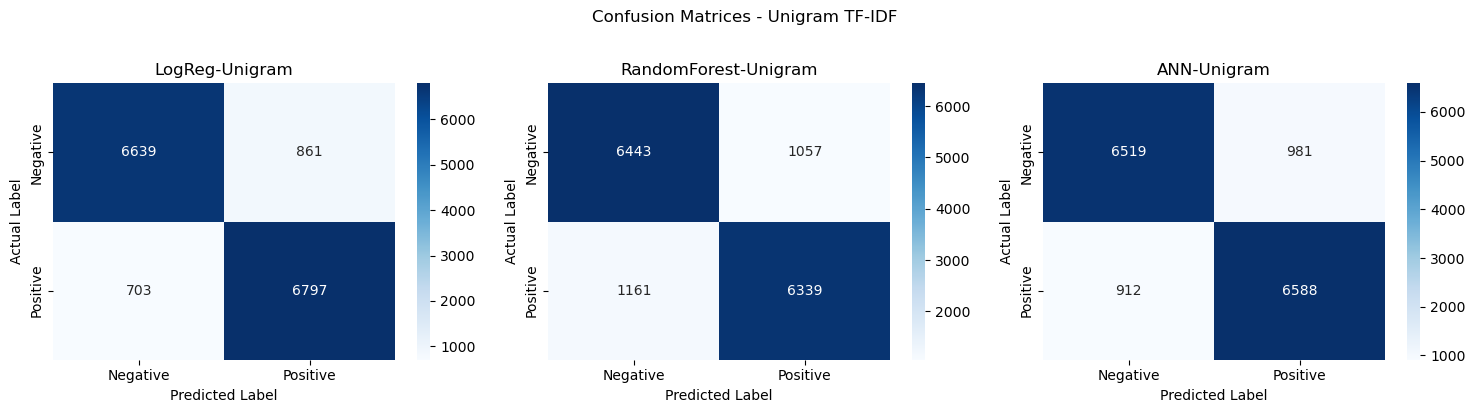

In [15]:
# ----------------------------------------------------------------
# Confusion matrices for the three primary classifiers using unigram TF-IDF.
#
# ----------------------------------------------------------------

primary_models = [
    "LogReg-Unigram",
    "RandomForest-Unigram",
    "ANN-Unigram"
]

results_lookup = {
    r["Model"]: r
    for r in results_q1
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, model_name in zip(axes, primary_models):
    result = results_lookup[model_name]
    
    cm = confusion_matrix(y_test, trained_models[model_name]["y_pred"])

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax,
        xticklabels=["Negative", "Positive"],
        yticklabels=["Negative", "Positive"]
    )

    ax.set_title(model_name)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("Actual Label")

plt.suptitle("Confusion Matrices - Unigram TF-IDF", y=1.02)
plt.tight_layout()
plt.show()

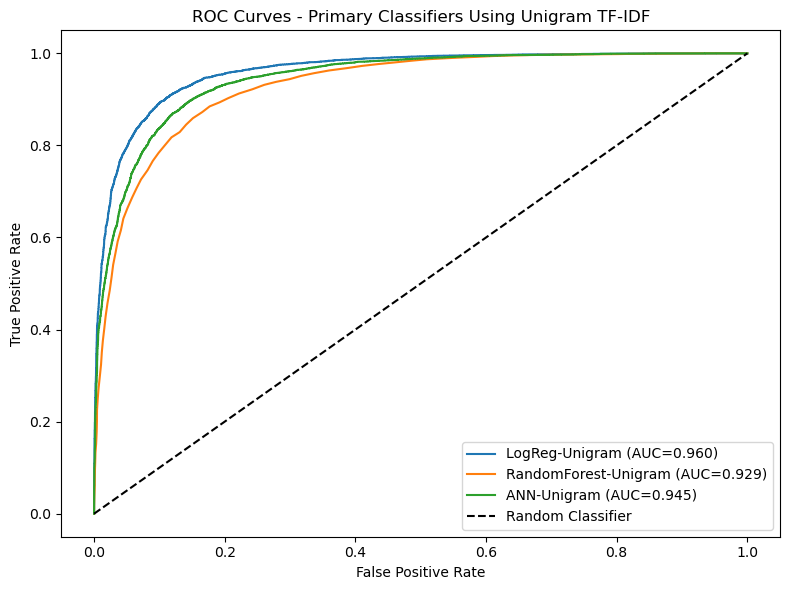

In [16]:
# ----------------------------------------------------------------
# ROC Curves for Primary Classifiers
# ----------------------------------------------------------------

primary_models = [
    "LogReg-Unigram",
    "RandomForest-Unigram",
    "ANN-Unigram"
]

results_lookup = {
    r["Model"]: r
    for r in results_q1
}

plt.figure(figsize=(8, 6))

for model_name in primary_models:
    result = results_lookup[model_name]

    y_prob = trained_models[model_name]["y_prob"]
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} (AUC={result['ROC-AUC']:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    "k--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Primary Classifiers Using Unigram TF-IDF")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [17]:
from pathlib import Path
import zipfile

# ----------------------------------------------------------------
# Load emotion classification dataset from emotions.zip
# ----------------------------------------------------------------

ZIP_PATH = Path("emotions.zip")

def load_emotion_split(zip_path, filename):
    """Read one split from the zip archive into a DataFrame."""

    records = []

    with zipfile.ZipFile(zip_path, "r") as zip_file:
        with zip_file.open(f"emotions/{filename}") as file:
            lines = file.read().decode("utf-8").splitlines()

    for line in lines:
        text, emotion = line.rsplit(";", 1)
        records.append({
            "text": text.strip(),
            "emotion": emotion.strip()
        })

    return pd.DataFrame(records)


df_train_em = load_emotion_split(ZIP_PATH, "train.txt")
df_test_em = load_emotion_split(ZIP_PATH, "test.txt")
df_val_em = load_emotion_split(ZIP_PATH, "val.txt")

print("Train:", df_train_em.shape)
print("Test :", df_test_em.shape)
print("Val  :", df_val_em.shape)

df_train_em.head()

Train: (16000, 2)
Test : (2000, 2)
Val  : (2000, 2)


,text,emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [18]:
# ----------------------------------------------------------------
# Dataset quality check with class percentages
# ----------------------------------------------------------------

def summarize_split(df, split_name):
    """Print dimensions, missing values, duplicates, and class distribution."""
    
    print(f"--- {split_name} ---")
    print("Dimensions :", df.shape)
    print("Missing    :", df.isnull().sum().to_dict())
    print("Duplicates :", df.duplicated().sum())

    class_summary = pd.DataFrame({
        "count": df["emotion"].value_counts(),
        "percent": df["emotion"].value_counts(normalize=True).mul(100).round(2)
    })

    print("\nClass distribution:")
    print(class_summary)
    print()


splits = {
    "Train": df_train_em,
    "Test": df_test_em,
    "Val": df_val_em
}

for split_name, df_split in splits.items():
    summarize_split(df_split, split_name)

--- Train ---
Dimensions : (16000, 2)
Missing    : {'text': 0, 'emotion': 0}
Duplicates : 1

Class distribution:
          count  percent
emotion                 
joy        5362    33.51
sadness    4666    29.16
anger      2159    13.49
fear       1937    12.11
love       1304     8.15
surprise    572     3.58

--- Test ---
Dimensions : (2000, 2)
Missing    : {'text': 0, 'emotion': 0}
Duplicates : 0

Class distribution:
          count  percent
emotion                 
joy         695    34.75
sadness     581    29.05
anger       275    13.75
fear        224    11.20
love        159     7.95
surprise     66     3.30

--- Val ---
Dimensions : (2000, 2)
Missing    : {'text': 0, 'emotion': 0}
Duplicates : 0

Class distribution:
          count  percent
emotion                 
joy         704    35.20
sadness     550    27.50
anger       275    13.75
fear        212    10.60
love        178     8.90
surprise     81     4.05



In [19]:
# ----------------------------------------------------------------
# Average sentence length
# ----------------------------------------------------------------

df_train_em["sent_len"] = df_train_em["text"].str.split().str.len()

sentence_length_summary = (
    df_train_em
    .groupby("emotion")
    .agg(
        average_sentence_length=("sent_len", "mean"),
        median_sentence_length=("sent_len", "median"),
        sample_count=("sent_len", "count")
    )
    .round(2)
    .sort_values(by="average_sentence_length", ascending=False)
)

sentence_length_summary

,average_sentence_length,median_sentence_length,sample_count
emotion,,,
love,20.70,19.0,1304
surprise,19.97,18.0,572
joy,19.50,18.0,5362
anger,19.23,17.0,2159
fear,18.84,17.0,1937
sadness,18.36,16.0,4666


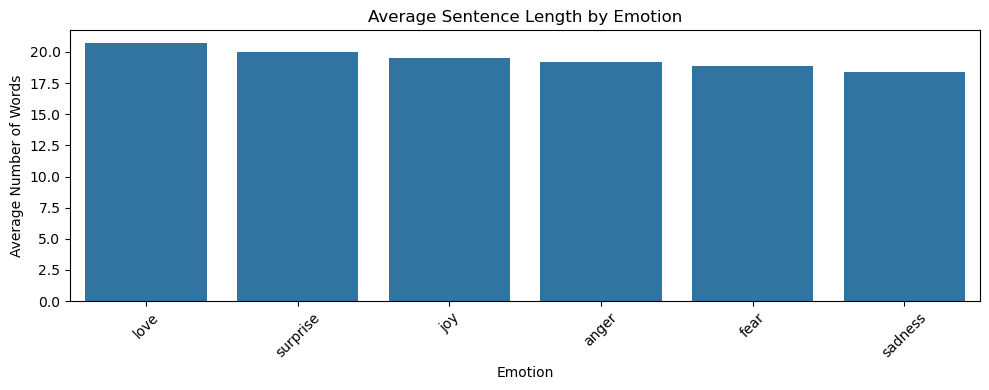

In [20]:
plt.figure(figsize=(10, 4))

sns.barplot(
    data=sentence_length_summary.reset_index(),
    x="emotion",
    y="average_sentence_length"
)

plt.title("Average Sentence Length by Emotion")
plt.xlabel("Emotion")
plt.ylabel("Average Number of Words")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

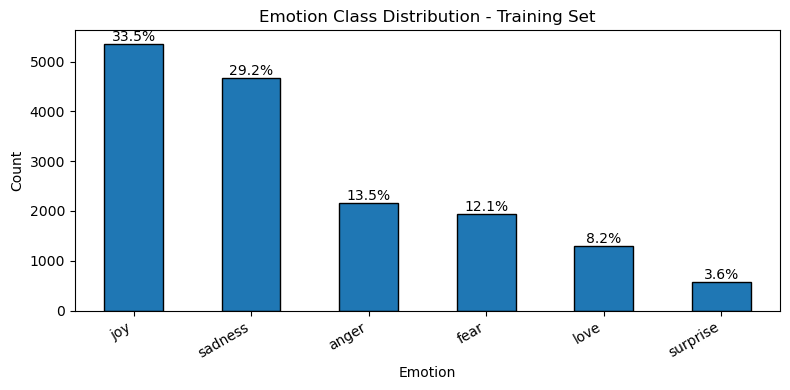

In [21]:
# ----------------------------------------------------------------
# Class imbalance visualization with percentages
# ----------------------------------------------------------------

emotion_counts = df_train_em["emotion"].value_counts()
emotion_percentages = df_train_em["emotion"].value_counts(normalize=True).mul(100)

plt.figure(figsize=(8, 4))

ax = emotion_counts.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Emotion Class Distribution - Training Set")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.xticks(rotation=30, ha="right")

for i, count in enumerate(emotion_counts):
    ax.text(
        i,
        count,
        f"{emotion_percentages.iloc[i]:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

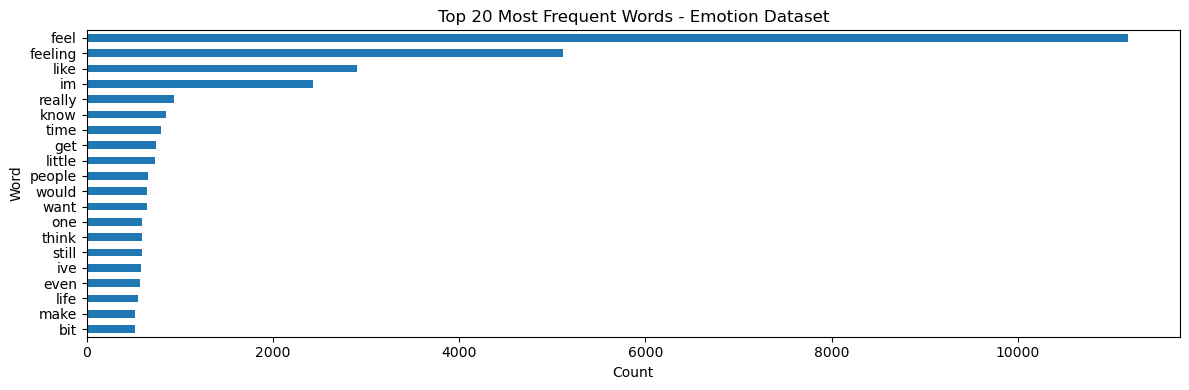

In [22]:
# ----------------------------------------------------------------
# Most frequent meaningful words 
# ----------------------------------------------------------------

stop_words = set(stopwords.words("english"))

top_em_words_clean = (
    df_train_em["text"]
    .str.lower()
    .str.replace(r"[^a-z\s]", " ", regex=True)
    .str.split()
    .explode()
)

top_em_words_clean = (
    top_em_words_clean[
        top_em_words_clean.notna() &
        ~top_em_words_clean.isin(stop_words)
    ]
    .value_counts()
    .head(20)
)

plt.figure(figsize=(12, 4))

top_em_words_clean.sort_values().plot(kind="barh")

plt.title("Top 20 Most Frequent Words - Emotion Dataset")
plt.xlabel("Count")
plt.ylabel("Word")
plt.tight_layout()
plt.show()

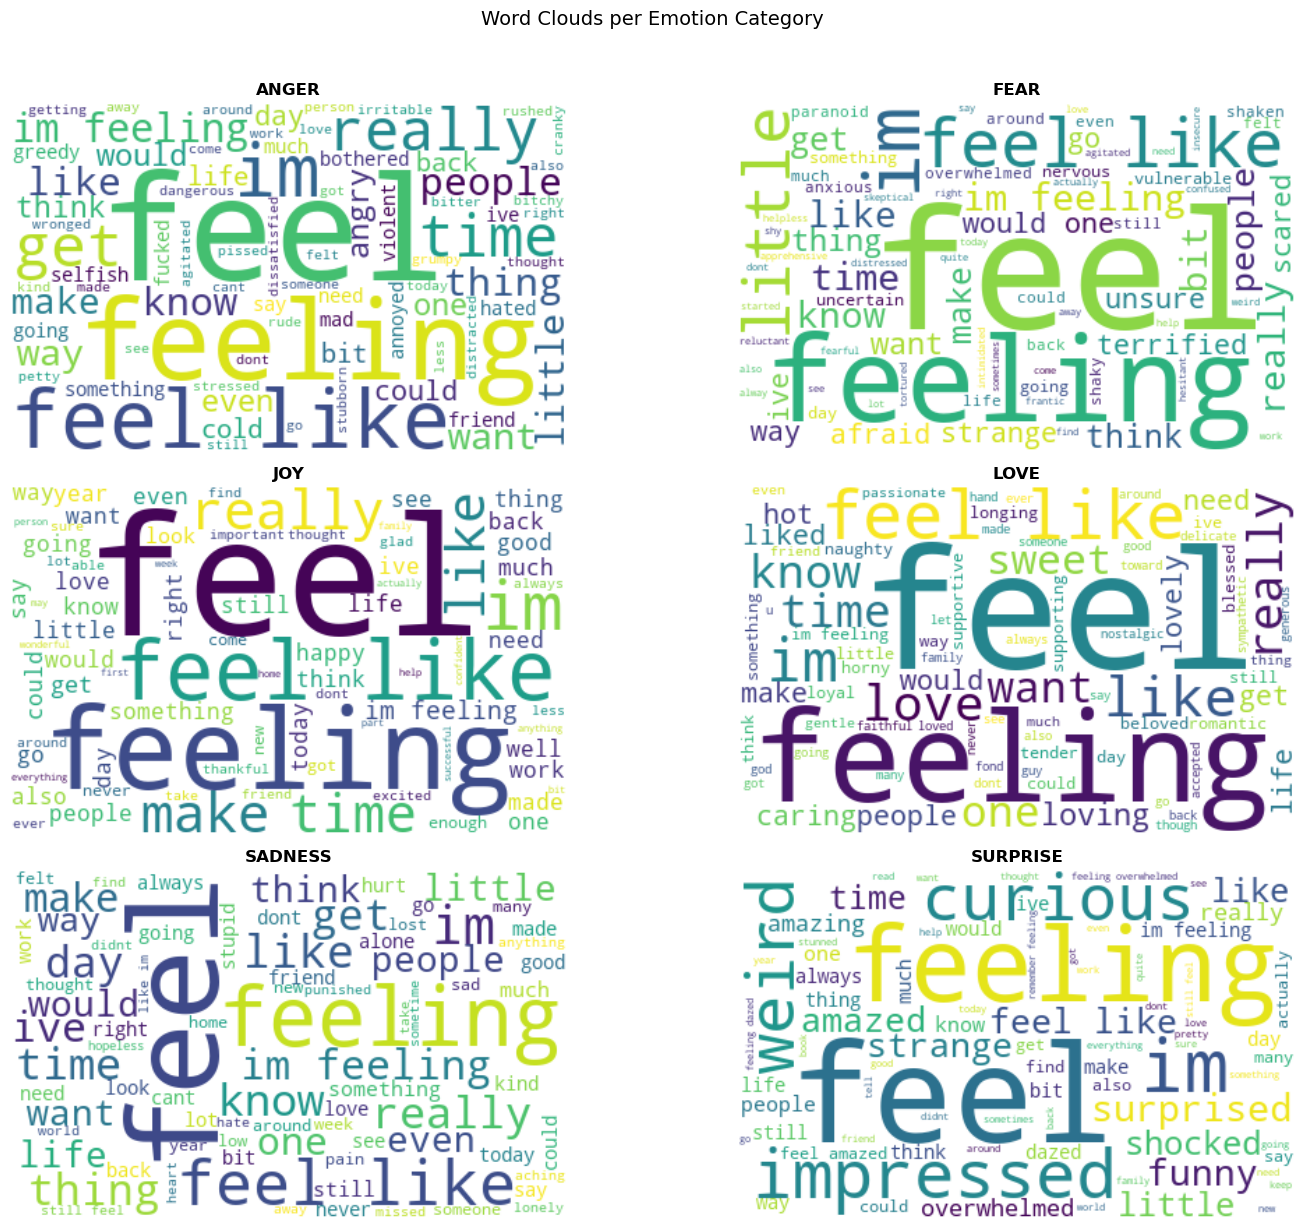

In [23]:
# ----------------------------------------------------------------
# Word clouds for each emotion category
# ----------------------------------------------------------------

emotion_labels = sorted(df_train_em["emotion"].unique())
n_emotions = len(emotion_labels)
n_cols = 2
n_rows = int(np.ceil(n_emotions / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = np.array(axes).flatten()

for ax, emotion in zip(axes, emotion_labels):
    emotion_text = " ".join(
        df_train_em.loc[df_train_em["emotion"] == emotion, "text"]
    )

    wc = WordCloud(
        width=400,
        height=250,
        background_color="white",
        max_words=80,
        stopwords=set(stopwords.words("english"))
    ).generate(emotion_text)

    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(emotion.upper(), fontsize=12, fontweight="bold")

for ax in axes[len(emotion_labels):]:
    ax.set_visible(False)

plt.suptitle("Word Clouds per Emotion Category", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [24]:
# ----------------------------------------------------------------
# Preprocess emotion text and encode emotion labels
# ----------------------------------------------------------------

def clean_text_column(df, text_col="text", clean_col="clean"):
    """Apply text preprocessing to a dataframe text column."""
    df = df.copy()
    df[clean_col] = df[text_col].apply(preprocess)
    return df


print("Cleaning training set...")
df_train_em = clean_text_column(df_train_em)

print("Cleaning validation set...")
df_val_em = clean_text_column(df_val_em)

print("Cleaning test set...")
df_test_em = clean_text_column(df_test_em)


# Encode emotion labels as integers
label_encoder = LabelEncoder()

y_train_em = label_encoder.fit_transform(df_train_em["emotion"])
y_val_em = label_encoder.transform(df_val_em["emotion"])
y_test_em = label_encoder.transform(df_test_em["emotion"])

print("Classes:", label_encoder.classes_)

Cleaning training set...
Cleaning validation set...
Cleaning test set...
Classes: ['anger' 'fear' 'joy' 'love' 'sadness' 'surprise']


In [25]:
# ----------------------------------------------------------------
# Use the 500 most frequent terms for BoW and TF-IDF features.
# ----------------------------------------------------------------

vocab_size = 500

vocab_500 = (
    df_train_em["clean"]
    .str.split()
    .explode()
    .value_counts()
    .head(vocab_size)
    .index
    .tolist()
)

print(f"Vocabulary size: {len(vocab_500)}")
print("Sample terms:", vocab_500[:20])

Vocabulary size: 500
Sample terms: ['feel', 'feeling', 'like', 'im', 'time', 'really', 'know', 'get', 'make', 'little', 'want', 'day', 'thing', 'people', 'one', 'would', 'think', 'life', 'still', 'ive']


In [26]:
bow_vectorizer = CountVectorizer(vocabulary=vocab_500)

X_train_bow = bow_vectorizer.fit_transform(df_train_em["clean"])
X_val_bow = bow_vectorizer.transform(df_val_em["clean"])
X_test_bow = bow_vectorizer.transform(df_test_em["clean"])

In [27]:
tfidf_vectorizer = TfidfVectorizer(vocabulary=vocab_500)

X_train_tfidf_em = tfidf_vectorizer.fit_transform(df_train_em["clean"])
X_val_tfidf_em = tfidf_vectorizer.transform(df_val_em["clean"])
X_test_tfidf_em = tfidf_vectorizer.transform(df_test_em["clean"])

In [28]:
# ----------------------------------------------------------------
# Bag-of-Words (BoW)
# ----------------------------------------------------------------

bow_vectorizer = CountVectorizer(vocabulary=vocab_500)

X_train_bow = bow_vectorizer.fit_transform(df_train_em["clean"])
X_val_bow = bow_vectorizer.transform(df_val_em["clean"])
X_test_bow = bow_vectorizer.transform(df_test_em["clean"])

print("BoW train shape:", X_train_bow.shape)
print("BoW val shape  :", X_val_bow.shape)
print("BoW test shape :", X_test_bow.shape)

BoW train shape: (16000, 500)
BoW val shape  : (2000, 500)
BoW test shape : (2000, 500)


In [29]:
# ----------------------------------------------------------------
# TF-IDF Features
# ----------------------------------------------------------------

tfidf_vectorizer_em = TfidfVectorizer(vocabulary=vocab_500)

X_train_tfidf_em = tfidf_vectorizer_em.fit_transform(df_train_em["clean"])
X_val_tfidf_em = tfidf_vectorizer_em.transform(df_val_em["clean"])
X_test_tfidf_em = tfidf_vectorizer_em.transform(df_test_em["clean"])

print("TF-IDF train shape:", X_train_tfidf_em.shape)
print("TF-IDF val shape  :", X_val_tfidf_em.shape)
print("TF-IDF test shape :", X_test_tfidf_em.shape)

TF-IDF train shape: (16000, 500)
TF-IDF val shape  : (2000, 500)
TF-IDF test shape : (2000, 500)


In [30]:
# ----------------------------------------------------------------
# Word Embeddings using GloVe
# ----------------------------------------------------------------

from pathlib import Path

GLOVE_PATH = Path("glove.6B.100d.txt")
EMBED_DIM = 100


def load_glove(path):
    """Load GloVe embeddings into a dictionary."""

    embeddings = {}

    with open(path, "r", encoding="utf-8") as file:
        for line in file:
            values = line.split()
            word = values[0]
            vector = np.asarray(values[1:], dtype="float32")
            embeddings[word] = vector

    return embeddings


def document_to_average_embedding(text, embedding_dict, embedding_dim=100):
    """Convert one document into an average word embedding vector."""

    vectors = [
        embedding_dict[word]
        for word in text.split()
        if word in embedding_dict
    ]

    if len(vectors) == 0:
        return np.zeros(embedding_dim)

    return np.mean(vectors, axis=0)


def build_embedding_matrix(text_series, embedding_dict, embedding_dim=100):
    """Convert a pandas Series of text into an embedding matrix."""

    return np.vstack([
        document_to_average_embedding(text, embedding_dict, embedding_dim)
        for text in text_series
    ])


if GLOVE_PATH.exists():
    print("Loading GloVe embeddings...")

    glove_embeddings = load_glove(GLOVE_PATH)

    X_train_emb = build_embedding_matrix(
        df_train_em["clean"],
        glove_embeddings,
        EMBED_DIM
    )

    X_val_emb = build_embedding_matrix(
        df_val_em["clean"],
        glove_embeddings,
        EMBED_DIM
    )

    X_test_emb = build_embedding_matrix(
        df_test_em["clean"],
        glove_embeddings,
        EMBED_DIM
    )

    use_embeddings = True

    print("Embedding train shape:", X_train_emb.shape)
    print("Embedding val shape  :", X_val_emb.shape)
    print("Embedding test shape :", X_test_emb.shape)

else:
    use_embeddings = False

    print(f"GloVe file not found at: {GLOVE_PATH}")
    print("Embedding features were not created.")

GloVe file not found at: glove.6B.100d.txt
Embedding features were not created.


In [31]:
# ----------------------------------------------------------------
# Decision Tree with GridSearchCV
# ----------------------------------------------------------------

dt_param_grid = {
    "max_depth": [5, 10, 20, None],
    "min_samples_leaf": [1, 5, 10]
}

dt_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=dt_param_grid,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1
)

dt_grid.fit(X_train_tfidf_em, y_train_em)

best_dt = dt_grid.best_estimator_

print("Best Decision Tree Parameters:")
print(dt_grid.best_params_)

print("\nBest Cross-Validation Macro F1:")
print(round(dt_grid.best_score_, 4))

y_val_pred_dt = best_dt.predict(X_val_tfidf_em)

print("\nDecision Tree Validation Performance:")
print(classification_report(
    y_val_em,
    y_val_pred_dt,
    target_names=label_encoder.classes_
))

Best Decision Tree Parameters:
{'max_depth': None, 'min_samples_leaf': 10}

Best Cross-Validation Macro F1:
0.6109

Decision Tree Validation Performance:
              precision    recall  f1-score   support

       anger       0.67      0.55      0.60       275
        fear       0.60      0.52      0.56       212
         joy       0.61      0.69      0.65       704
        love       0.50      0.37      0.42       178
     sadness       0.58      0.62      0.60       550
    surprise       0.79      0.65      0.72        81

    accuracy                           0.60      2000
   macro avg       0.62      0.57      0.59      2000
weighted avg       0.60      0.60      0.60      2000



In [32]:
# ----------------------------------------------------------------
# Random Forest with RandomizedSearchCV
# ----------------------------------------------------------------

from scipy.stats import randint

rf_param_dist = {
    "n_estimators": randint(50, 200),
    "max_depth": [5, 10, 20, None],
    "max_features": ["sqrt", "log2"]
}

rf_random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        class_weight="balanced"
    ),
    param_distributions=rf_param_dist,
    n_iter=10,
    cv=3,
    scoring="f1_macro",
    random_state=42,
    n_jobs=-1
)

rf_random_search.fit(X_train_tfidf_em, y_train_em)

best_rf = rf_random_search.best_estimator_

print("Best Random Forest Parameters:")
print(rf_random_search.best_params_)

print("\nBest Cross-Validation Macro F1:")
print(round(rf_random_search.best_score_, 4))

y_val_pred_rf = best_rf.predict(X_val_tfidf_em)

print("\nRandom Forest Validation Performance:")
print(classification_report(
    y_val_em,
    y_val_pred_rf,
    target_names=label_encoder.classes_
))

Best Random Forest Parameters:
{'max_depth': 20, 'max_features': 'log2', 'n_estimators': 166}

Best Cross-Validation Macro F1:
0.6343

Random Forest Validation Performance:
              precision    recall  f1-score   support

       anger       0.79      0.56      0.65       275
        fear       0.73      0.48      0.58       212
         joy       0.67      0.67      0.67       704
        love       0.55      0.47      0.51       178
     sadness       0.56      0.71      0.63       550
    surprise       0.64      0.81      0.72        81

    accuracy                           0.64      2000
   macro avg       0.66      0.62      0.63      2000
weighted avg       0.65      0.64      0.63      2000



In [33]:
# ----------------------------------------------------------------
# ANN / MLP Classifier
# ----------------------------------------------------------------

ann_em = MLPClassifier(
    hidden_layer_sizes=(256, 128),
    activation="relu",
    max_iter=100,
    early_stopping=True,
    validation_fraction=0.10,
    random_state=42
)

ann_em.fit(X_train_tfidf_em, y_train_em)

y_val_pred_ann = ann_em.predict(X_val_tfidf_em)

print("ANN trained.")
print("Training iterations:", ann_em.n_iter_)

print("\nANN Validation Performance:")
print(classification_report(
    y_val_em,
    y_val_pred_ann,
    target_names=label_encoder.classes_
))

ANN trained.
Training iterations: 14

ANN Validation Performance:
              precision    recall  f1-score   support

       anger       0.78      0.52      0.62       275
        fear       0.62      0.49      0.54       212
         joy       0.65      0.78      0.71       704
        love       0.60      0.38      0.46       178
     sadness       0.59      0.68      0.64       550
    surprise       0.74      0.59      0.66        81

    accuracy                           0.64      2000
   macro avg       0.66      0.57      0.61      2000
weighted avg       0.65      0.64      0.63      2000



In [34]:
# ----------------------------------------------------------------
# Evaluate all three models on the test set.
# ----------------------------------------------------------------

def evaluate_multiclass_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Macro-Precision": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "Macro-Recall": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "Macro-F1": f1_score(y_test, y_pred, average="macro", zero_division=0)
    }

    return metrics, y_pred


models_em = {
    "DecisionTree": best_dt,
    "RandomForest": best_rf,
    "ANN-MLP": ann_em
}

results_em = []
predictions_em = {}

for model_name, model in models_em.items():
    metrics, y_pred = evaluate_multiclass_model(
        model,
        X_test_tfidf_em,
        y_test_em,
        model_name
    )

    results_em.append(metrics)
    predictions_em[model_name] = y_pred


metrics_em = (
    pd.DataFrame(results_em)
    .round(4)
    .sort_values(by="Macro-F1", ascending=False)
)

metrics_em

,Model,Accuracy,Macro-Precision,Macro-Recall,Macro-F1
2,ANN-MLP,0.6620,0.6810,0.5810,0.6175
1,RandomForest,0.6265,0.6297,0.6083,0.6020
0,DecisionTree,0.6210,0.5910,0.5539,0.5692


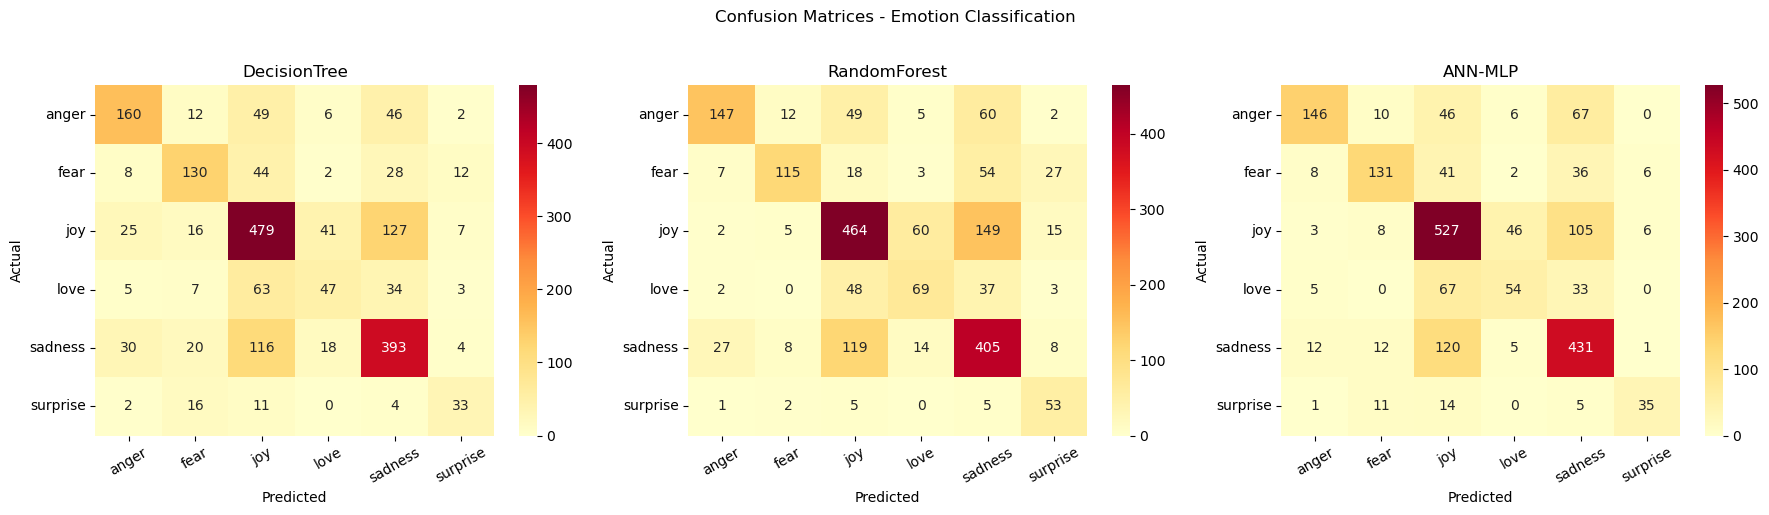

In [35]:
class_names = label_encoder.classes_

# Attach predictions to each result dict for confusion matrix plotting
for result in results_em:
    model_name = result["Model"]
    if "y_pred" not in result and model_name in predictions_em:
        result["y_pred"] = predictions_em[model_name]

fig, axes = plt.subplots(1, len(results_em), figsize=(6 * len(results_em), 5))

if len(results_em) == 1:
    axes = [axes]

for ax, result in zip(axes, results_em):
    cm = confusion_matrix(y_test_em, result["y_pred"])

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="YlOrRd",
        ax=ax,
        xticklabels=class_names,
        yticklabels=class_names
    )

    ax.set_title(result["Model"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.tick_params(axis="x", rotation=30)
    ax.tick_params(axis="y", rotation=0)

plt.suptitle("Confusion Matrices - Emotion Classification", y=1.02)
plt.tight_layout()
plt.show()

In [36]:
# ----------------------------------------------------------------
# Predict emotions for 5 new sentences using the best classifier.
# ----------------------------------------------------------------

model_lookup = {
    "DecisionTree": best_dt,
    "RandomForest": best_rf,
    "ANN-MLP": ann_em
}

best_em_model_name = metrics_em.loc[
    metrics_em["Macro-F1"].idxmax(),
    "Model"
]

best_em_model = model_lookup[best_em_model_name]

print(f"Best model: {best_em_model_name}")

new_sentences = [
    "I feel completely devastated after losing my wallet.",
    "I am excited about my graduation ceremony.",
    "Everything feels so gloomy and I cannot stop crying.",
    "I was furious when they cancelled our plans at the last minute.",
    "There is a warm sense of gratitude in my heart today."
]

new_clean = [preprocess(sentence) for sentence in new_sentences]
new_features = tfidf_vectorizer_em.transform(new_clean)

predictions = best_em_model.predict(new_features)
predicted_labels = label_encoder.inverse_transform(predictions)

if hasattr(best_em_model, "predict_proba"):
    probabilities = best_em_model.predict_proba(new_features)
    confidence_scores = probabilities.max(axis=1)
else:
    confidence_scores = [None] * len(new_sentences)

prediction_df = pd.DataFrame({
    "Sentence": new_sentences,
    "Predicted Emotion": predicted_labels,
    "Confidence": confidence_scores
})

prediction_df

Best model: ANN-MLP


,Sentence,Predicted Emotion,Confidence
0,I feel completely devastated after losing my w...,sadness,0.995788
1,I am excited about my graduation ceremony.,joy,0.963617
2,Everything feels so gloomy and I cannot stop c...,sadness,0.986825
3,I was furious when they cancelled our plans at...,joy,0.646351
4,There is a warm sense of gratitude in my heart...,sadness,0.445939


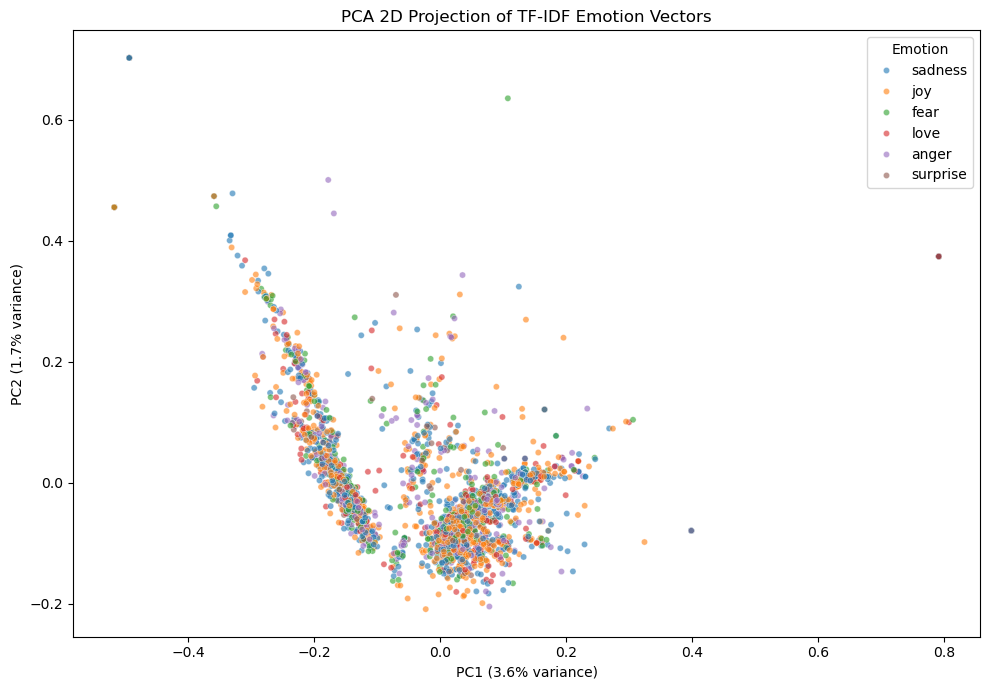

In [37]:
# ----------------------------------------------------------------
# PCA Visualization with Sampling
# ----------------------------------------------------------------

sample_size = min(3000, X_train_tfidf_em.shape[0])

sample_indices = np.random.RandomState(42).choice(
    X_train_tfidf_em.shape[0],
    size=sample_size,
    replace=False
)

X_sample = X_train_tfidf_em[sample_indices].toarray()
y_sample_labels = df_train_em["emotion"].values[sample_indices]

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_sample)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "emotion": y_sample_labels
})

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="emotion",
    s=20,
    alpha=0.6
)

plt.title("PCA 2D Projection of TF-IDF Emotion Vectors")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)")
plt.legend(title="Emotion")
plt.tight_layout()
plt.show()

K=3  Inertia=4410.7  Silhouette=0.0926
K=4  Inertia=4132.3  Silhouette=0.0837
K=5  Inertia=4002.5  Silhouette=0.0780
K=6  Inertia=3952.8  Silhouette=0.0801
K=7  Inertia=3817.5  Silhouette=0.0882
K=8  Inertia=3517.9  Silhouette=0.1171
K=9  Inertia=3478.4  Silhouette=0.1200
K=10  Inertia=3416.9  Silhouette=0.1243


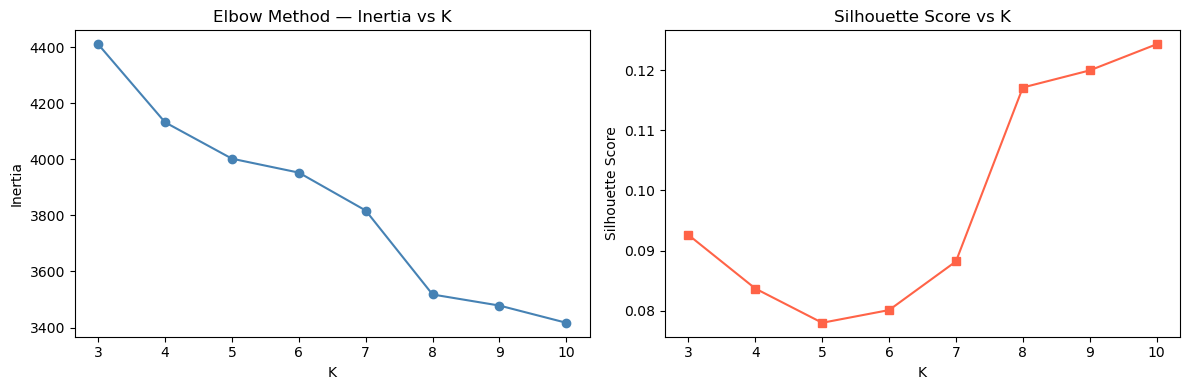

Optimal K (highest silhouette): 10


In [38]:
# ----------------------------------------------------------------
# K-Means Clustering on Emotion Text Data
# ----------------------------------------------------------------

from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from sklearn.pipeline import make_pipeline
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score

inertias    = []
silhouettes = []
K_range     = range(3, 11)

# Reduce to 50 dims first for speed (PCA does not distort clustering much)
pca50 = PCA(n_components=50, random_state=42)
X_50  = pca50.fit_transform(X_train_tfidf_em.toarray())

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    km.fit(X_50)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_50, km.labels_, sample_size=2000, random_state=42)
    silhouettes.append(sil)
    print(f'K={k}  Inertia={km.inertia_:.1f}  Silhouette={sil:.4f}')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(K_range), inertias, 'o-', color='steelblue')
axes[0].set_title('Elbow Method — Inertia vs K')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertia')

axes[1].plot(list(K_range), silhouettes, 's-', color='tomato')
axes[1].set_title('Silhouette Score vs K')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

optimal_k = list(K_range)[np.argmax(silhouettes)]
print(f'Optimal K (highest silhouette): {optimal_k}')



In [39]:
# ----------------------------------------------------------------
# Assign clusters to test documents using the final K-Means model.
# ----------------------------------------------------------------

km_final = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
km_final.fit(X_50)

# Transform test set to same 50-dim PCA space, then assign clusters
X_test_50    = pca50.transform(X_test_tfidf_em.toarray())
test_clusters = km_final.predict(X_test_50)

df_test_em['cluster'] = test_clusters
print('Test set cluster distribution:')
print(df_test_em['cluster'].value_counts().sort_index())

Test set cluster distribution:
cluster
0     94
1    400
2     95
3     48
4     25
5    170
6    831
7    227
8     31
9     79
Name: count, dtype: int64


In [68]:
cluster_emotion_table = pd.crosstab(
    df_test_em["cluster"],
    df_test_em["emotion"]
)

cluster_emotion_table

emotion,anger,fear,joy,love,sadness,surprise
cluster,,,,,,
0,21,5,32,8,25,3
1,61,67,121,25,116,10
2,11,12,33,6,28,5
3,6,6,14,6,16,0
4,3,0,12,1,9,0
5,26,23,51,11,55,4
6,111,81,301,69,235,34
7,23,20,83,29,65,7
8,2,1,20,0,8,0


In [69]:
# ----------------------------------------------------------------
# Load image caption dataset
# ----------------------------------------------------------------

df_caps = pd.read_csv('image_caption.txt', sep='\t')
df_caps.columns = df_caps.columns.str.strip()   # clean any leading spaces

print('Shape:', df_caps.shape)
df_caps.head(4)

Shape: (1000, 2)


,ID,caption
0,ImageCLEFmedCaption_2022_train_000001,pericardial tamponade with clear distinction o...
1,ImageCLEFmedCaption_2022_train_000002,angiography of the aortic arch show delay visu...
2,ImageCLEFmedCaption_2022_train_000003,balloonocclude retrograde transvenous oblitera...
3,ImageCLEFmedCaption_2022_train_000004,film after glue embolization show no filling i...


In [70]:
# ----------------------------------------------------------------
# Lighter preprocessing for medical image captions
# ----------------------------------------------------------------

def preprocess_medical(text: str) -> str:
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words and len(t) > 1]
    return ' '.join(tokens)

df_caps['clean'] = df_caps['caption'].astype(str).apply(preprocess_medical)
df_caps.head(3)

,ID,caption,clean
0,ImageCLEFmedCaption_2022_train_000001,pericardial tamponade with clear distinction o...,pericardial tamponade clear distinction epicar...
1,ImageCLEFmedCaption_2022_train_000002,angiography of the aortic arch show delay visu...,angiography aortic arch show delay visualizati...
2,ImageCLEFmedCaption_2022_train_000003,balloonocclude retrograde transvenous oblitera...,balloonocclude retrograde transvenous oblitera...


In [71]:
# ----------------------------------------------------------------
# TF-IDF Document-Term Matrix for medical captions
# ----------------------------------------------------------------

tfidf_med = TfidfVectorizer(max_features=5000)
TDM = tfidf_med.fit_transform(df_caps['clean'])

print('Term-Document Matrix shape:', TDM.shape,
      '  (rows=documents, cols=terms)')

Term-Document Matrix shape: (1000, 2645)   (rows=documents, cols=terms)


In [72]:
# ----------------------------------------------------------------
# TF-IDF Retrieval Pipeline
# ----------------------------------------------------------------

def retrieve_tfidf(query: str, tdm, vectorizer, df, top_k=10):
    """Return the top-K captions most similar to the query (TF-IDF)."""
    q_clean = preprocess_medical(query)
    q_vec   = vectorizer.transform([q_clean])       # sparse (1, V)
    sims    = cosine_similarity(q_vec, tdm).flatten()  # shape (N,)
    top_idx = np.argsort(sims)[::-1][:top_k]        # descending order
    results = df.iloc[top_idx][['ID', 'caption']].copy()
    results['cosine_sim'] = sims[top_idx]
    return results.reset_index(drop=True)

Q1 = "angiographic image shows normal coronary artery"
Q2 = "CT scan demonstrating pulmonary embolism"

print('=== TF-IDF Results for Q1 ===')
res_q1_tfidf = retrieve_tfidf(Q1, TDM, tfidf_med, df_caps)
print(res_q1_tfidf.to_string(index=False))

print('\n=== TF-IDF Results for Q2 ===')
res_q2_tfidf = retrieve_tfidf(Q2, TDM, tfidf_med, df_caps)
print(res_q2_tfidf.to_string(index=False))

=== TF-IDF Results for Q1 ===
                                   ID                                                                                                                                                                         caption  cosine_sim
ImageCLEFmedCaption_2022_train_000019                                                                                                                                  angiographic image show normal coronary artery    0.966911
ImageCLEFmedCaption_2022_train_000756                                                                                                                                                    normal leave coronary artery    0.660022
ImageCLEFmedCaption_2022_train_000382                                                                                                                  coronary angiography with normal coronary angiographic finding    0.657725
ImageCLEFmedCaption_2022_train_000755                             

In [73]:
# ----------------------------------------------------------------
# Word embedding retrieval using GloVe
# ----------------------------------------------------------------

from pathlib import Path

GLOVE_PATH = Path(GLOVE_PATH)

if GLOVE_PATH.exists():
    print("Loading GloVe embeddings...")

    if "glove" not in globals():
        glove = load_glove(GLOVE_PATH)

    cap_embeddings = np.vstack([
        doc_to_avg_embedding(text, glove, EMBED_DIM)
        for text in df_caps["clean"]
    ])

    use_glove_retrieval = True

    print("Caption embedding matrix shape:", cap_embeddings.shape)

else:
    use_glove_retrieval = False
    glove = None
    cap_embeddings = None

    print(f"GloVe file not found at: {GLOVE_PATH}")
    print("Skipping GloVe embedding retrieval.")

GloVe file not found at: glove.6B.100d.txt
Skipping GloVe embedding retrieval.


In [75]:
# ----------------------------------------------------------------
# Compare TF-IDF vs GloVe top-5 result IDs side-by-side
# ----------------------------------------------------------------

# Ensure GloVe retrieval results exist (fall back to empty DataFrame if unavailable)

for query, r_tfidf, r_glove in [
    (Q1, res_q1_tfidf, res_q1_glove),
    (Q2, res_q2_tfidf, res_q2_glove)
]:
    print(f'Query: "{query}"')
    # Build fixed-length (top-5) views so all arrays have equal length
    tf = (
        r_tfidf.reindex(columns=["ID", "cosine_sim"])
        .head(5)
        .reset_index(drop=True)
        .reindex(range(5))
    )

    gl = (
        r_glove.reindex(columns=["ID", "cosine_sim"])
        .head(5)
        .reset_index(drop=True)
        .reindex(range(5))
    )

    comp = pd.DataFrame({
        "TF-IDF ID": tf["ID"],
        "TF-IDF sim": pd.to_numeric(tf["cosine_sim"], errors="coerce").round(4),
        "GloVe ID": gl["ID"],
        "GloVe sim": pd.to_numeric(gl["cosine_sim"], errors="coerce").round(4),
    })
    print(comp.to_string(index=False))
    print()

Query: "angiographic image shows normal coronary artery"
                            TF-IDF ID  TF-IDF sim GloVe ID  GloVe sim
ImageCLEFmedCaption_2022_train_000019      0.9669      NaN        NaN
ImageCLEFmedCaption_2022_train_000756      0.6600      NaN        NaN
ImageCLEFmedCaption_2022_train_000382      0.6577      NaN        NaN
ImageCLEFmedCaption_2022_train_000755      0.4983      NaN        NaN
ImageCLEFmedCaption_2022_train_000809      0.4453      NaN        NaN

Query: "CT scan demonstrating pulmonary embolism"
                            TF-IDF ID  TF-IDF sim GloVe ID  GloVe sim
ImageCLEFmedCaption_2022_train_000014      0.3374      NaN        NaN
ImageCLEFmedCaption_2022_train_000262      0.2531      NaN        NaN
ImageCLEFmedCaption_2022_train_000892      0.2383      NaN        NaN
ImageCLEFmedCaption_2022_train_000631      0.2113      NaN        NaN
ImageCLEFmedCaption_2022_train_000512      0.1877      NaN        NaN



In [77]:
def compare_retrieval_results(query, r_tfidf, r_glove, top_k=5):
    """
    Return a fixed-length side-by-side comparison DataFrame for TF-IDF vs GloVe.
    Handles missing/empty inputs and ensures numeric similarity columns.
    """
    # Helper to produce a fixed-length view
    def _fixed_view(df):
        if df is None or df.empty:
            return pd.DataFrame({
                "ID": [None] * top_k,
                "cosine_sim": [np.nan] * top_k
            })
        view = df.reindex(columns=["ID", "cosine_sim"]).head(top_k).reset_index(drop=True)
        view = view.reindex(range(top_k))  # ensure length top_k
        return view

    tf = _fixed_view(r_tfidf)
    gl = _fixed_view(r_glove)

    # Ensure numeric dtype for similarities
    tf["cosine_sim"] = pd.to_numeric(tf["cosine_sim"], errors="coerce").round(4)
    gl["cosine_sim"] = pd.to_numeric(gl["cosine_sim"], errors="coerce").round(4)

    comp = pd.DataFrame({
        "Rank": list(range(1, top_k + 1)),
        "TF-IDF ID": tf["ID"].fillna(""),
        "TF-IDF sim": tf["cosine_sim"],
        "GloVe ID": gl["ID"].fillna(""),
        "GloVe sim": gl["cosine_sim"],
    })

    comp["Query"] = query
    return comp[["Query", "Rank", "TF-IDF ID", "TF-IDF sim", "GloVe ID", "GloVe sim"]]


comparison_q1 = compare_retrieval_results(
    Q1,
    res_q1_tfidf,
    res_q1_glove,
    top_k=5
)

comparison_q1

,Query,Rank,TF-IDF ID,TF-IDF sim,GloVe ID,GloVe sim
0,angiographic image shows normal coronary artery,1,ImageCLEFmedCaption_2022_train_000019,0.9669,,NaN
1,angiographic image shows normal coronary artery,2,ImageCLEFmedCaption_2022_train_000756,0.6600,,NaN
2,angiographic image shows normal coronary artery,3,ImageCLEFmedCaption_2022_train_000382,0.6577,,NaN
3,angiographic image shows normal coronary artery,4,ImageCLEFmedCaption_2022_train_000755,0.4983,,NaN
4,angiographic image shows normal coronary artery,5,ImageCLEFmedCaption_2022_train_000809,0.4453,,NaN


In [78]:
comparison_q2 = compare_retrieval_results(
    Q2,
    res_q2_tfidf,
    res_q2_glove,
    top_k=5
)

comparison_q2

,Query,Rank,TF-IDF ID,TF-IDF sim,GloVe ID,GloVe sim
0,CT scan demonstrating pulmonary embolism,1,ImageCLEFmedCaption_2022_train_000014,0.3374,,NaN
1,CT scan demonstrating pulmonary embolism,2,ImageCLEFmedCaption_2022_train_000262,0.2531,,NaN
2,CT scan demonstrating pulmonary embolism,3,ImageCLEFmedCaption_2022_train_000892,0.2383,,NaN
3,CT scan demonstrating pulmonary embolism,4,ImageCLEFmedCaption_2022_train_000631,0.2113,,NaN
4,CT scan demonstrating pulmonary embolism,5,ImageCLEFmedCaption_2022_train_000512,0.1877,,NaN


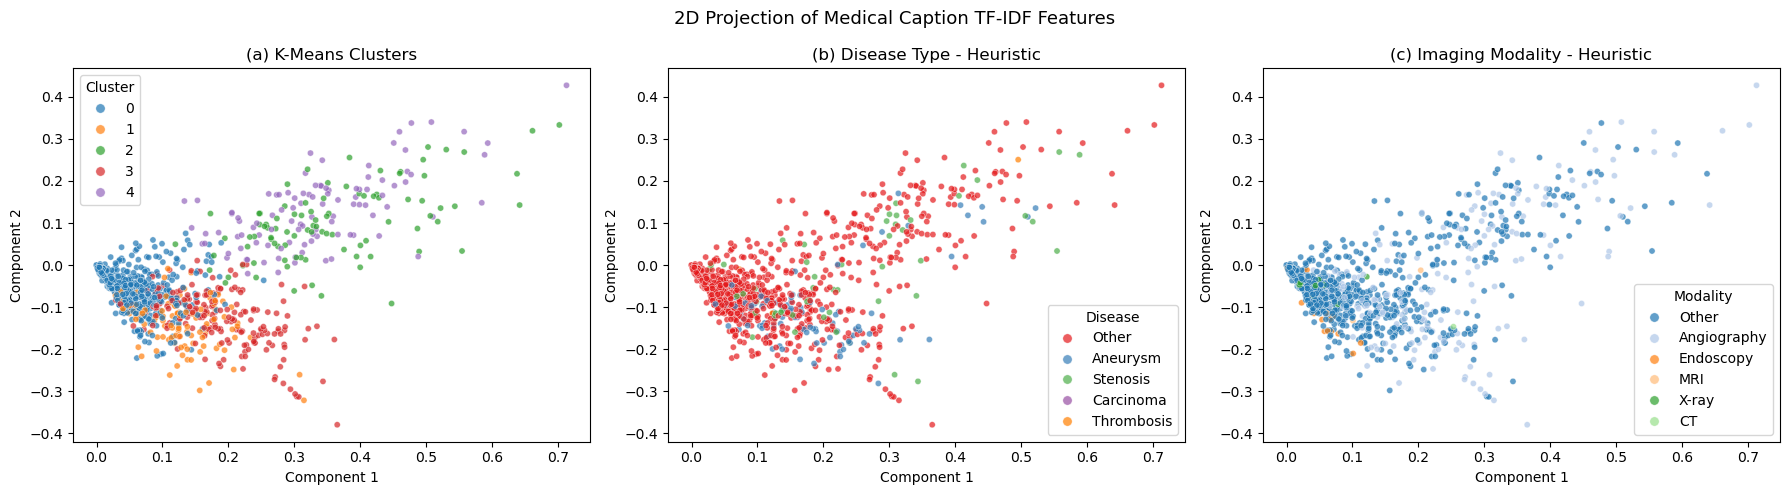

In [79]:
# ----------------------------------------------------------------
# Visualize TF-IDF medical caption embeddings in 2D.
# ----------------------------------------------------------------

from sklearn.decomposition import TruncatedSVD

X_med = TDM   # or X_tfidf_med if you renamed it earlier

# Reduce sparse TF-IDF matrix to 2D
svd_med = TruncatedSVD(n_components=2, random_state=42)
X_med_2d = svd_med.fit_transform(X_med)

# K-Means clustering
km_med = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

km_labels = km_med.fit_predict(X_med)

# Keyword dictionaries
disease_keywords = {
    "aneurysm": "Aneurysm",
    "embolism": "Embolism",
    "carcinoma": "Carcinoma",
    "stenosis": "Stenosis",
    "thrombosis": "Thrombosis"
}

modality_keywords = {
    r"\bct\b": "CT",
    r"\bmri\b": "MRI",
    r"\bx[\-\s]?ray\b": "X-ray",
    r"\bultrasound\b": "Ultrasound",
    r"\bangiograph\w*\b": "Angiography",
    r"\bendoscop\w*\b": "Endoscopy"
}


def detect_keyword(text, keyword_map, default_label="Other"):
    text = str(text).lower()
    
    for pattern, label in keyword_map.items():
        if re.search(pattern, text):
            return label
    
    return default_label


df_caps = df_caps.copy()

df_caps["disease"] = df_caps["caption"].apply(
    lambda text: detect_keyword(text, disease_keywords, "Other")
)

df_caps["modality"] = df_caps["caption"].apply(
    lambda text: detect_keyword(text, modality_keywords, "Other")
)

plot_df = pd.DataFrame({
    "Component 1": X_med_2d[:, 0],
    "Component 2": X_med_2d[:, 1],
    "Cluster": km_labels,
    "Disease": df_caps["disease"],
    "Modality": df_caps["modality"]
})

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(
    data=plot_df,
    x="Component 1",
    y="Component 2",
    hue="Cluster",
    palette="tab10",
    s=20,
    alpha=0.7,
    ax=axes[0]
)

axes[0].set_title("(a) K-Means Clusters")
axes[0].legend(title="Cluster", markerscale=1.5)

sns.scatterplot(
    data=plot_df,
    x="Component 1",
    y="Component 2",
    hue="Disease",
    palette="Set1",
    s=20,
    alpha=0.7,
    ax=axes[1]
)

axes[1].set_title("(b) Disease Type - Heuristic")
axes[1].legend(title="Disease", markerscale=1.5)

sns.scatterplot(
    data=plot_df,
    x="Component 1",
    y="Component 2",
    hue="Modality",
    palette="tab20",
    s=20,
    alpha=0.7,
    ax=axes[2]
)

axes[2].set_title("(c) Imaging Modality - Heuristic")
axes[2].legend(title="Modality", markerscale=1.5)

plt.suptitle("2D Projection of Medical Caption TF-IDF Features", fontsize=13)
plt.tight_layout()
plt.show()

In [81]:
# ----------------------------------------------------------------
#  streamlit run app.py
# ----------------------------------------------------------------

streamlit_code = '''
# ============================================================
# app.py - Medical Image Caption Retrieval Web Interface
# Run with: streamlit run app.py
# ============================================================

from pathlib import Path
import re
import string

import streamlit as st
import pandas as pd
import numpy as np
import nltk

from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


# ------------------------------------------------------------------
# Constants
# ------------------------------------------------------------------

CAPTION_FILE = Path("image_caption.txt")
GLOVE_PATH = Path("glove.6B.100d.txt")
EMBED_DIM = 100

nltk.download("stopwords", quiet=True)
STOP_WORDS = set(stopwords.words("english"))


# ------------------------------------------------------------------
# Preprocessing
# ------------------------------------------------------------------

def preprocess_medical(text: str) -> str:
    """
    Lightly clean medical caption text:
    - lowercase
    - remove punctuation and numbers
    - remove stop words
    """

    if pd.isna(text):
        return ""

    text = str(text).lower()
    text = re.sub(r"[^a-z\\s]", " ", text)

    tokens = [
        token
        for token in text.split()
        if token not in STOP_WORDS and len(token) > 1
    ]

    return " ".join(tokens)


# ------------------------------------------------------------------
# Cached data loading
# ------------------------------------------------------------------

@st.cache_data
def load_data():
    """Load and preprocess the caption dataset."""

    if not CAPTION_FILE.exists():
        st.error(f"Caption file not found: {CAPTION_FILE}")
        st.stop()

    df = pd.read_csv(CAPTION_FILE, sep="\\t")
    df.columns = df.columns.str.strip()

    required_columns = {"ID", "caption"}
    missing_columns = required_columns - set(df.columns)

    if missing_columns:
        st.error(f"Missing required columns: {missing_columns}")
        st.stop()

    df["clean"] = df["caption"].apply(preprocess_medical)

    return df


@st.cache_resource
def build_tfidf(clean_text):
    """Build TF-IDF vectorizer and document-term matrix."""

    vectorizer = TfidfVectorizer(
        max_features=5000,
        min_df=2,
        max_df=0.90,
        sublinear_tf=True
    )

    tfidf_matrix = vectorizer.fit_transform(clean_text)

    return vectorizer, tfidf_matrix


@st.cache_resource
def load_glove_embeddings(clean_text):
    """
    Load GloVe embeddings and pre-compute caption embeddings.
    Returns None values if GloVe file is unavailable.
    """

    if not GLOVE_PATH.exists():
        return None, None

    embeddings = {}

    with open(GLOVE_PATH, "r", encoding="utf-8") as file:
        for line in file:
            values = line.split()
            word = values[0]
            vector = np.asarray(values[1:], dtype="float32")
            embeddings[word] = vector

    caption_embeddings = np.vstack([
        average_embedding(text, embeddings)
        for text in clean_text
    ])

    return embeddings, caption_embeddings


def average_embedding(text, embedding_dict):
    """Convert text into an average GloVe embedding vector."""

    vectors = [
        embedding_dict[word]
        for word in text.split()
        if word in embedding_dict
    ]

    if not vectors:
        return np.zeros(EMBED_DIM)

    return np.mean(vectors, axis=0)


# ------------------------------------------------------------------
# Retrieval helpers
# ------------------------------------------------------------------

def tfidf_retrieve(query, df, vectorizer, tfidf_matrix, top_k=10):
    """Return top-K captions using TF-IDF cosine similarity."""

    query_clean = preprocess_medical(query)

    if not query_clean:
        return pd.DataFrame(columns=["ID", "caption", "similarity"])

    query_vector = vectorizer.transform([query_clean])

    similarity_scores = cosine_similarity(
        query_vector,
        tfidf_matrix
    ).flatten()

    top_k = min(top_k, len(df))
    top_indices = np.argsort(similarity_scores)[::-1][:top_k]

    results = df.iloc[top_indices][["ID", "caption"]].copy()
    results["similarity"] = similarity_scores[top_indices].round(4)

    return results.reset_index(drop=True)


def glove_retrieve(query, df, embedding_dict, caption_embeddings, top_k=10):
    """Return top-K captions using GloVe average embedding similarity."""

    query_clean = preprocess_medical(query)
    query_vector = average_embedding(query_clean, embedding_dict)

    if np.all(query_vector == 0):
        return pd.DataFrame(columns=["ID", "caption", "similarity"])

    similarity_scores = cosine_similarity(
        query_vector.reshape(1, -1),
        caption_embeddings
    ).flatten()

    top_k = min(top_k, len(df))
    top_indices = np.argsort(similarity_scores)[::-1][:top_k]

    results = df.iloc[top_indices][["ID", "caption"]].copy()
    results["similarity"] = similarity_scores[top_indices].round(4)

    return results.reset_index(drop=True)


# ------------------------------------------------------------------
# Streamlit UI
# ------------------------------------------------------------------

st.set_page_config(
    page_title="Medical Caption Retrieval",
    layout="wide"
)

st.title("Medical Image Caption Retrieval")

st.markdown(
    """
    Search medical image captions using **TF-IDF** and optional **GloVe**
    word embeddings.
    """
)


# Load resources
df = load_data()
tfidf_vectorizer, tfidf_matrix = build_tfidf(df["clean"])
glove_dict, caption_embeddings = load_glove_embeddings(df["clean"])


# Sidebar controls
st.sidebar.header("Search Settings")

top_k = st.sidebar.slider(
    "Number of results",
    min_value=5,
    max_value=10,
    value=10
)

method = st.sidebar.selectbox(
    "Retrieval method",
    ["TF-IDF", "GloVe", "Both"]
)


# Query input
preset_queries = [
    "angiographic image shows normal coronary artery",
    "CT scan demonstrating pulmonary embolism",
    "MRI showing brain tumor mass",
    "ultrasound of gallbladder with stones",
    "Custom query"
]

selected_query = st.selectbox(
    "Choose a preset query or enter your own:",
    preset_queries
)

if selected_query == "Custom query":
    query = st.text_input("Enter your query:")
else:
    query = selected_query
    st.text_input("Active query:", value=query, disabled=True)


# Search button
if st.button("Search"):
    if not query.strip():
        st.warning("Please enter a query before searching.")
        st.stop()

    st.markdown(f"**Query:** `{query}`")

    if method in ["TF-IDF", "Both"]:
        st.subheader("TF-IDF Results")

        tfidf_results = tfidf_retrieve(
            query,
            df,
            tfidf_vectorizer,
            tfidf_matrix,
            top_k
        )

        if tfidf_results.empty:
            st.warning("No TF-IDF results found for this query.")
        else:
            st.dataframe(tfidf_results, use_container_width=True)

    if method in ["GloVe", "Both"]:
        st.subheader("GloVe Embedding Results")

        if glove_dict is None or caption_embeddings is None:
            st.warning(
                f"GloVe file not found at `{GLOVE_PATH}`. "
                "Place `glove.6B.100d.txt` in the same folder as app.py "
                "to enable embedding retrieval."
            )
        else:
            glove_results = glove_retrieve(
                query,
                df,
                glove_dict,
                caption_embeddings,
                top_k
            )

            if glove_results.empty:
                st.warning(
                    "No GloVe results found. The query may not contain words "
                    "covered by the GloVe vocabulary."
                )
            else:
                st.dataframe(glove_results, use_container_width=True)
'''

with open("app.py", "w", encoding="utf-8") as file:
    file.write(streamlit_code)

print("app.py written. Run: streamlit run app.py")

app.py written. Run: streamlit run app.py
